<a href="https://colab.research.google.com/github/Thrilcrazyer/Data_Structures_2026/blob/main/Code/ArrayMax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. 개발 환경
- 본 실습에서 개발 환경은 Python 에서 기본적으로 제공하는 Tool인 IDLE로 제한합니다.


[설치링크](https://www.python.org/downloads/)




# 1. 배열(Array)
- **동일한 타입**의 데이터를 **연속된 메모리 공간**에 저장하는 자료구조

### 배열의 구조

| 인덱스 | 0 | 1 | 2 | 3 | 4 | $\cdots$ | n−1 |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **값** | A[0] | A[1] | A[2] | A[3] | A[4] | $\cdots$ | A[n−1] |
| **주소** | base | base+4 | base+8 | base+12 | base+16 | $\cdots$ | base+4(n−1) |

- `int`형 기준 각 원소는 **4바이트** 크기이므로, 주소가 4씩 증가

### 주소 계산 공식

$$\text{addr}(A[i]) = \text{base address} + i \times \text{sizeof(element)}$$


### Python에서의 배열

- Python은 `list`라는 내장 자료구조를 통해 배열 기능을 제공하며, 본 강의에서 다루는 **Array**보다 상위 개념으로 구현되어 있습니다. (그래도 비슷한 개념으로)
- 이 내용은 **Vector** 강의에서 추가로 설명합니다.
- 본 실습강의에서는 **Vector** 수업 전까지 ctypes.Array를 통해 Array를 구현합니다

In [33]:
import random
import ctypes


n= 10

## C Style
### 배열을 생성

In [34]:
# 배열 선언
ArrayType = ctypes.c_int * n
A = ArrayType()

# 데이터 입력
for i in range(n):
  A[i] = random.randint(1, 100)

### 생성된 배열을 확인

In [43]:
print(A)

A_addr = ctypes.addressof(A)

for i in range(n):
    addr = A_addr + i * ctypes.sizeof(ctypes.c_int)
    print(f"{i}번째 주소: {addr}")
    print(f"{i}번째 주소의 값: {ctypes.c_int.from_address(addr).value}, 값: {A[i]}")

0번째 주소: 140115299485232
0번째 주소의 값: 31, 값: 31
1번째 주소: 140115299485236
1번째 주소의 값: 31, 값: 31
2번째 주소: 140115299485240
2번째 주소의 값: 39, 값: 39
3번째 주소: 140115299485244
3번째 주소의 값: 44, 값: 44
4번째 주소: 140115299485248
4번째 주소의 값: 44, 값: 44
5번째 주소: 140115299485252
5번째 주소의 값: 45, 값: 45
6번째 주소: 140115299485256
6번째 주소의 값: 48, 값: 48
7번째 주소: 140115299485260
7번째 주소의 값: 79, 값: 79
8번째 주소: 140115299485264
8번째 주소의 값: 85, 값: 85
9번째 주소: 140115299485268
9번째 주소의 값: 90, 값: 90


## Pythonic Style

### 리스트 형태의 배열을 생성

In [36]:
A = [random.randint(1, 100) for i in range(n)]

print(A)

[49, 40, 23, 94, 69, 6, 47, 89, 12, 17]


## 코드 실습

`DS_AL_ch1_algorithm기초_U.pdf, 17 page`

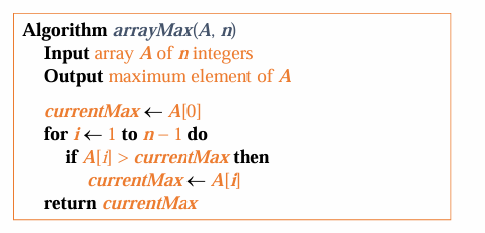

In [44]:
def arrayMax(A:ctypes.Array, n:int) -> int:
    currentMax=A[0]
    for i in range(1, n):
        if A[i] > currentMax:
            currentMax = A[i]
    return currentMax

print(arrayMax(A, n))

90


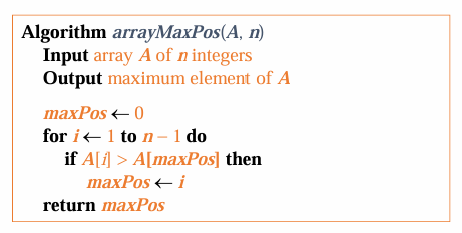

In [45]:
index=int

def arrayMaxPos(A:ctypes.Array, n:int) -> index:
    maxPos: index = 0
    for i in range(1,n):
        if A[i] > A[maxPos]:
            maxPos = i
    return maxPos

print(arrayMaxPos(A, n))

9


`DS_AL_ch1_algorithm기초_U.pdf, 21 page`

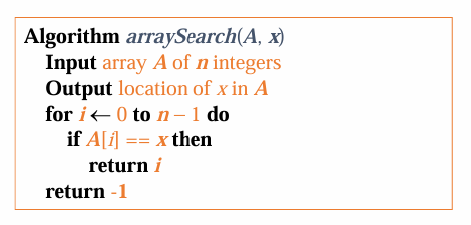

In [39]:
def arraySearch(A:ctypes.Array, n:int, key:int) -> index:
    for i in range(n):
        if A[i] == key:
            return i
    return -1
print(arraySearch(A, n, 50))

-1


`DS_AL_ch1_algorithm기초_U.pdf, 24 page`

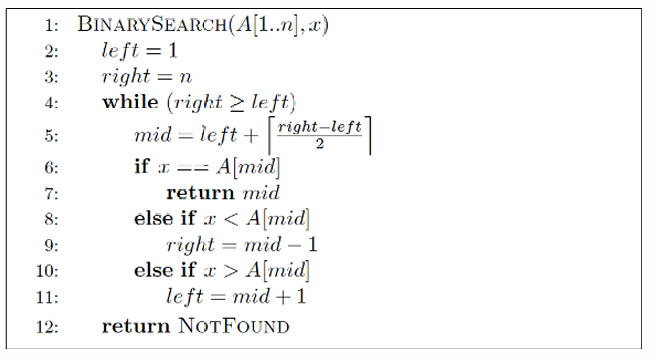

In [40]:
def binarySearch(A:ctypes.Array,n:int,x:int) -> index:
    left=0
    right=n-1
    while right >= left:
        middle=(left+right)//2
        if A[middle] == x:
            return middle
        elif A[middle] < x:
            left = middle + 1
        else:
            right = middle - 1
    return "404 New Error ERA"

print(binarySearch(A, n, 11))

404 New Error ERA


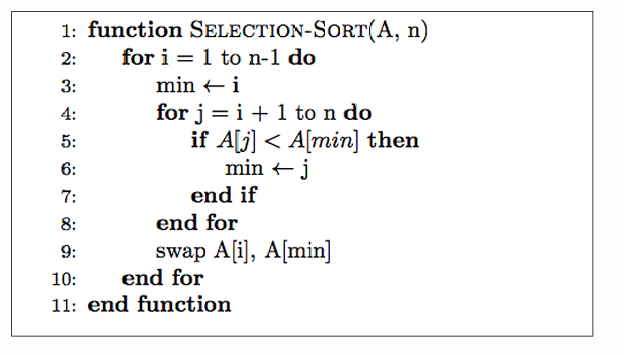

In [41]:
def selectionSort(A:ctypes.Array, n:int) -> None:
    for i in range(n-1):
        minPos = i
        for j in range(i+1, n):
            if A[j] < A[minPos]:
                minPos = j
        A[i], A[minPos] = A[minPos], A[i]


######################################################

n=10
A = (ctypes.c_int * n)()

for i in range(n):
    A[i] = random.randint(1, 100)
    print(A[i], end=' ')

print()

selectionSort(A, n)

for i in range(n):
    print(A[i], end=' ')

98 22 64 81 14 67 39 51 39 95 
14 22 39 39 51 64 67 81 95 98 

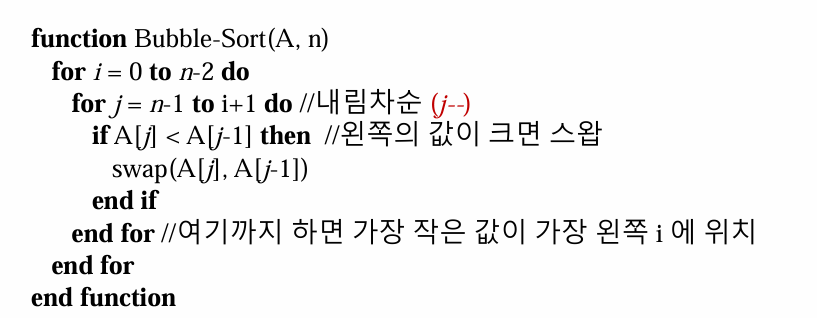

In [42]:
def bubbleSort(A:ctypes.Array, n:int) -> None:
    for i in range(0,n-1):
        for j in range(n-1, i, -1):
            if A[j] < A[j-1]:
                A[j], A[j-1] = A[j-1], A[j] # SWAP (Pythonic)

#######################################################

n=10
A = (ctypes.c_int * n)()

for i in range(n):
    A[i] = random.randint(1, 100)
    print(A[i], end=' ')

print()

bubbleSort(A, n)

for i in range(n):
    print(A[i], end=' ')

39 31 85 79 44 48 90 44 31 45 
31 31 39 44 44 45 48 79 85 90 

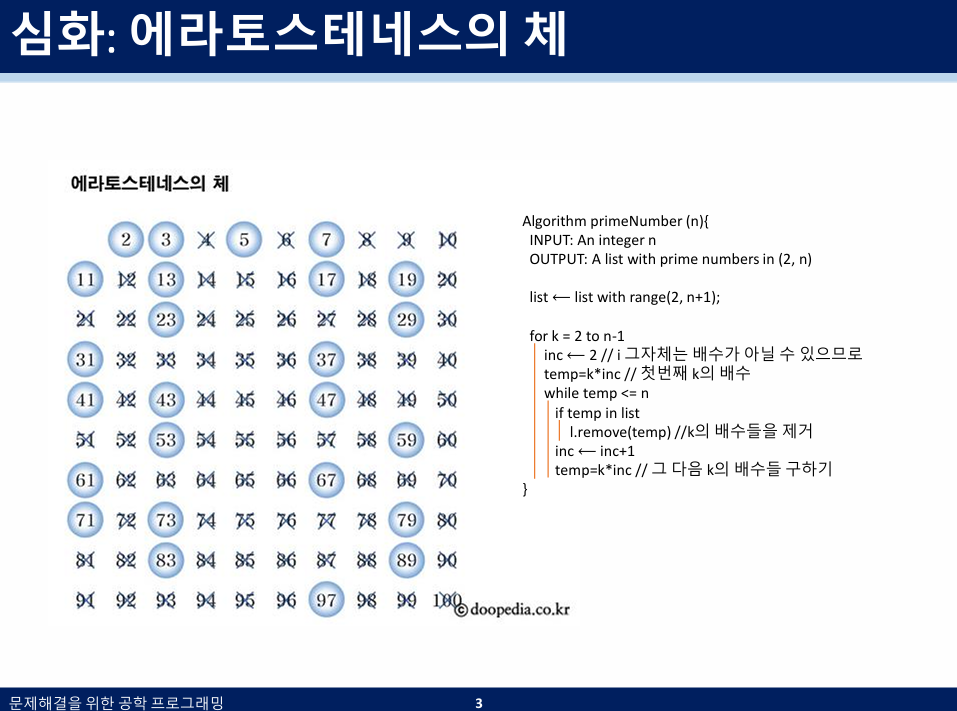

# 실습: 에라토스테네스의 체 구현

- `DS_AL_ch2_algorithm분석.pdf` 3페이지에 제시된 알고리즘을 참고하여 소수를 구하는 코드를 작성하시오.
- 제공된 템플릿을 바탕으로 다음 항목을 구현하시오.

1. 주어진 정수가 소수인지 판별하는 `isPrime(n: int) -> bool` 함수를 구현하시오.
2. `n` 이하의 모든 소수를 찾아 `bool` 배열로 반환하는 `sieveOfEratosthenes(n: int) -> ctypes.Array` 함수를 구현하시오.
3. 1번 방식으로 `n` 이하의 모든 소수를 찾는 `getPrimeNumbers(n: int) -> ctypes.Array` 함수를 작성하고, 이 함수와 `sieveOfEratosthenes(n: int) -> ctypes.Array` 함수의 실행 시간을 비교한 뒤 그 차이가 발생하는 이유를 분석하시오.